In [25]:
# Core
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

In [26]:
df = pd.read_csv("/content/cleaned_data (1).csv")

In [27]:
df.head()


,text,type,type_encoded,char_length,word_count,avg_word_length,unique_word_ratio
0,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...,Incident,1,783,84,8.333333,0.869048
1,"Account Disruption Dear Customer Support Team,...",Incident,1,563,84,5.714286,0.833333
2,Query About Smart Home System Integration Feat...,Request,3,585,83,6.060241,0.819277
3,Inquiry Regarding Invoice Details Dear Custome...,Request,3,639,95,5.736842,0.768421
4,Question About Marketing Agency Software Compa...,Problem,2,732,103,6.116505,0.776699


In [28]:
# 3. Prepare Features

X = df["text"]
y = df["type_encoded"]

df.shape

(28587, 7)

In [29]:
# 4. Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

Train Size: (22869,)
Test Size: (5718,)


In [30]:
# 5. TF-IDF Vectorizer


tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

In [31]:
# 6. Build Pipelines

log_reg_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

svm_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

rf_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [32]:
# 7. Train & Evaluate

models = {
    "Logistic Regression": log_reg_pipeline,
    "Linear SVM": svm_pipeline,
    "Random Forest": rf_pipeline
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")

    results[name] = {
        "accuracy": acc,
        "f1_macro": f1
    }

    print("Accuracy:", round(acc, 4))
    print("F1 Macro:", round(f1, 4))


Training Logistic Regression...
Accuracy: 0.8265
F1 Macro: 0.8406

Training Linear SVM...
Accuracy: 0.8519
F1 Macro: 0.8597

Training Random Forest...
Accuracy: 0.8319
F1 Macro: 0.7997


In [33]:
# 8. Model Comparison

comparison_df = pd.DataFrame(results).T.sort_values("f1_macro", ascending=False)
comparison_df

,accuracy,f1_macro
Linear SVM,0.851871,0.859676
Logistic Regression,0.826513,0.840565
Random Forest,0.831934,0.799659


In [34]:
# 9. Best Model Analysis

best_model_name = comparison_df.index[0]
best_model = models[best_model_name]

preds = best_model.predict(X_test)

print("Best Model:", best_model_name)
print("\nClassification Report:\n")

print(classification_report(y_test, preds))

Best Model: Linear SVM

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       584
           1       0.81      0.83      0.82      2293
           2       0.67      0.64      0.66      1203
           3       0.99      0.99      0.99      1638

    accuracy                           0.85      5718
   macro avg       0.86      0.86      0.86      5718
weighted avg       0.85      0.85      0.85      5718



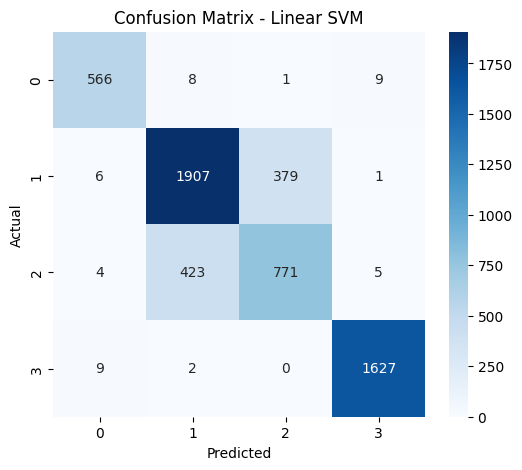

In [35]:
# 10. Confusion Matrix

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
# 11. Cross Validation


cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean CV F1:", np.mean(cv_scores))


Cross-Validation F1 Scores: [0.82501294 0.84882354 0.85734361 0.85418774 0.86296919]
Mean CV F1: 0.8496674044151952


In [37]:
# 12. Save Model


joblib.dump(best_model, "best_model.pkl")

print("Model Saved Successfully.")

Model Saved Successfully.
